# DCT-Domain Transient Sketchpad

This notebook treats the DCT coefficient axis like a drawable domain. We draw a waveform across DCT bins, then apply `IDCT` to see the short time-domain transient that comes out.

Important distinction:

- This is **not** ordinary additive harmonic synthesis.
- The curves below are **DCT coefficient profiles**, not time-domain bass waves.
- A smooth sinusoid drawn across DCT bins can become a localized impulse after IDCT.
- Saw/square/triangle coefficient-domain shapes contain sharper coefficient-domain edges, so their IDCT responses produce different transient shapes and side lobes.

This is close to the DDSP-SFX idea for the transient branch: predict compact DCT-domain parameters, then use IDCT to produce short impulse-like events.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

try:
    from scipy.fft import idct
except Exception:  # scipy < 1.4 fallback
    from scipy.fftpack import idct

from IPython.display import Audio, display

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True

# A 10 ms frame at 16 kHz matches the DDSP-SFX paper's example scale.
sr = 16_000
frame_ms = 10.0
N = int(round(sr * frame_ms / 1000.0))

# Number of periods drawn across the DCT coefficient axis.
# Try 1, 2, 4, 8, 16. This behaves like a transient-location/timbre control.
coefficient_cycles = 4.0
phase = 0.0

wave_types = ['sine', 'saw', 'square', 'triangle']

print(f'sr={sr} Hz, frame={frame_ms} ms, N={N} samples, coefficient_cycles={coefficient_cycles}')


sr=16000 Hz, frame=10.0 ms, N=160 samples, coefficient_cycles=4.0


## Build Waveforms in the DCT Coefficient Domain

The horizontal axis below is the DCT coefficient index `k`, normalized to `[0, 1)`. We draw one waveform across that axis.

`coeff[0]` is forced to zero to remove DC offset in the resulting transient.


In [2]:
def normalize_peak(x, eps=1e-12):
    return x / (np.max(np.abs(x)) + eps)


def coefficient_axis(n):
    return np.arange(n, dtype=np.float64) / float(n)


def waveform_on_unit_phase(kind, unit_phase):
    """Periodic waveform defined on phase in [0, 1)."""
    phase_wrapped = np.mod(unit_phase, 1.0)

    if kind == 'sine':
        return np.sin(2.0 * np.pi * phase_wrapped)

    if kind in {'saw', 'salt'}:  # 'salt' is kept as a typo-tolerant alias for saw.
        return 2.0 * phase_wrapped - 1.0

    if kind == 'square':
        return np.where(phase_wrapped < 0.5, 1.0, -1.0)

    if kind == 'triangle':
        return 1.0 - 4.0 * np.abs(phase_wrapped - 0.5)

    raise ValueError(f'unknown waveform type: {kind}')


def high_bin_taper(n, strength=0.0):
    """Optional smooth rolloff near high DCT bins. strength=0 keeps the raw drawn profile."""
    if strength <= 0:
        return np.ones(n, dtype=np.float64)
    u = coefficient_axis(n)
    return np.cos(0.5 * np.pi * u) ** float(strength)


def make_dct_profile(kind, n=N, cycles=coefficient_cycles, phase=phase, taper_strength=0.0):
    u = coefficient_axis(n)
    coeff = waveform_on_unit_phase(kind, cycles * u + phase)
    coeff = coeff * high_bin_taper(n, taper_strength)
    coeff = coeff - coeff.mean()
    coeff[0] = 0.0
    return normalize_peak(coeff)


def idct_transient(coeff):
    x = idct(coeff, type=2, norm='ortho')
    return normalize_peak(x)

profiles = {
    kind: make_dct_profile(kind)
    for kind in wave_types
}

responses = {
    kind: idct_transient(profile)
    for kind, profile in profiles.items()
}


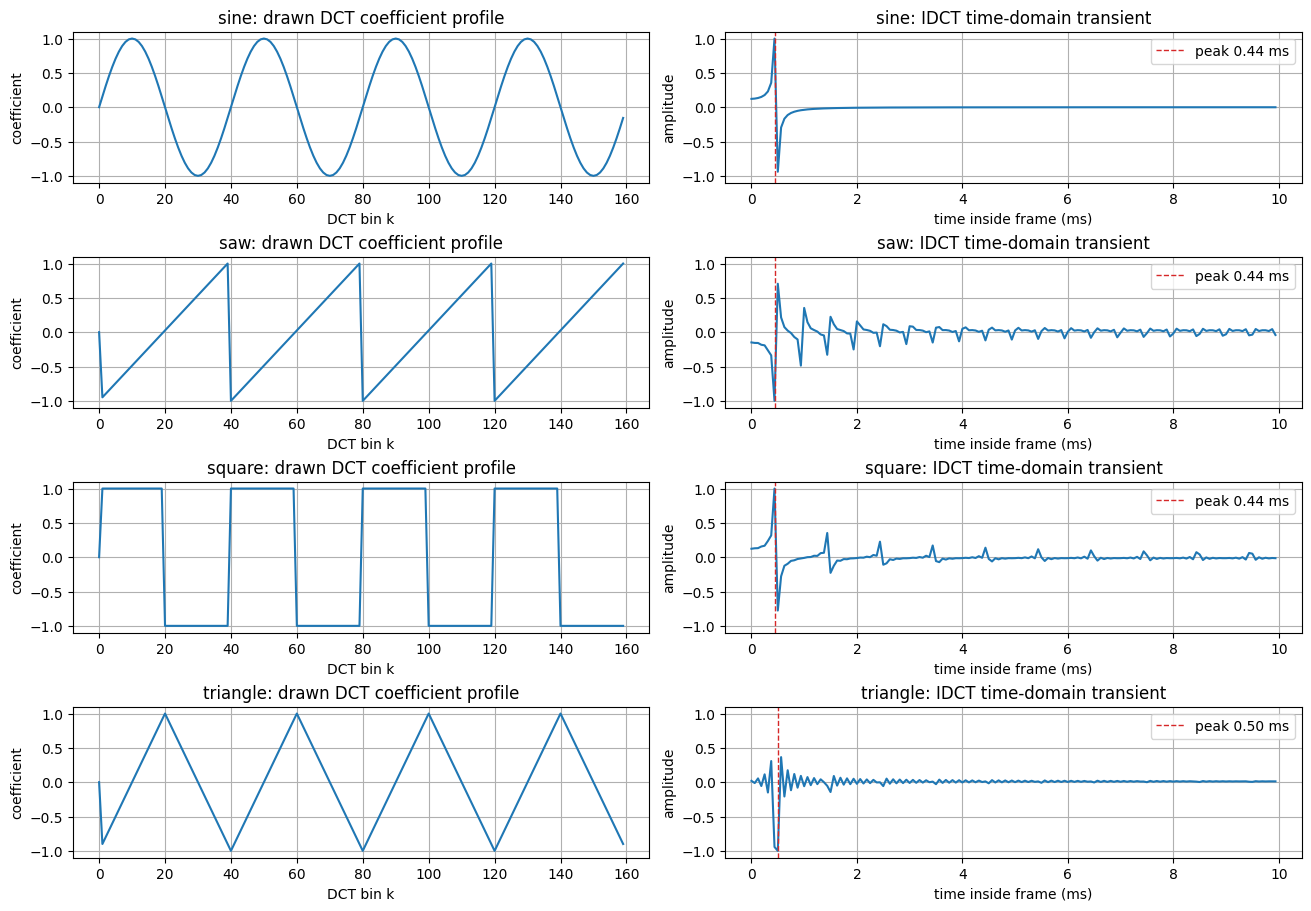

In [3]:
fig, axes = plt.subplots(len(wave_types), 2, figsize=(13, 9), constrained_layout=True)
k = np.arange(N)
time_ms = np.arange(N) / sr * 1000.0

for row, kind in enumerate(wave_types):
    profile = profiles[kind]
    response = responses[kind]
    peak_idx = int(np.argmax(np.abs(response)))

    ax = axes[row, 0]
    ax.plot(k, profile, linewidth=1.5)
    ax.set_title(f'{kind}: drawn DCT coefficient profile')
    ax.set_xlabel('DCT bin k')
    ax.set_ylabel('coefficient')
    ax.set_ylim(-1.1, 1.1)

    ax = axes[row, 1]
    ax.plot(time_ms, response, linewidth=1.5)
    ax.axvline(time_ms[peak_idx], color='tab:red', linestyle='--', linewidth=1.0, label=f'peak {time_ms[peak_idx]:.2f} ms')
    ax.set_title(f'{kind}: IDCT time-domain transient')
    ax.set_xlabel('time inside frame (ms)')
    ax.set_ylabel('amplitude')
    ax.set_ylim(-1.1, 1.1)
    ax.legend(loc='upper right')

plt.show()


## Overlay: How the Four Coefficient Shapes Become Different Transients

The DCT-domain waveform controls the time-domain impulse shape. The result is usually not a single clean click; side lobes, polarity, and peak location are part of the transient timbre.


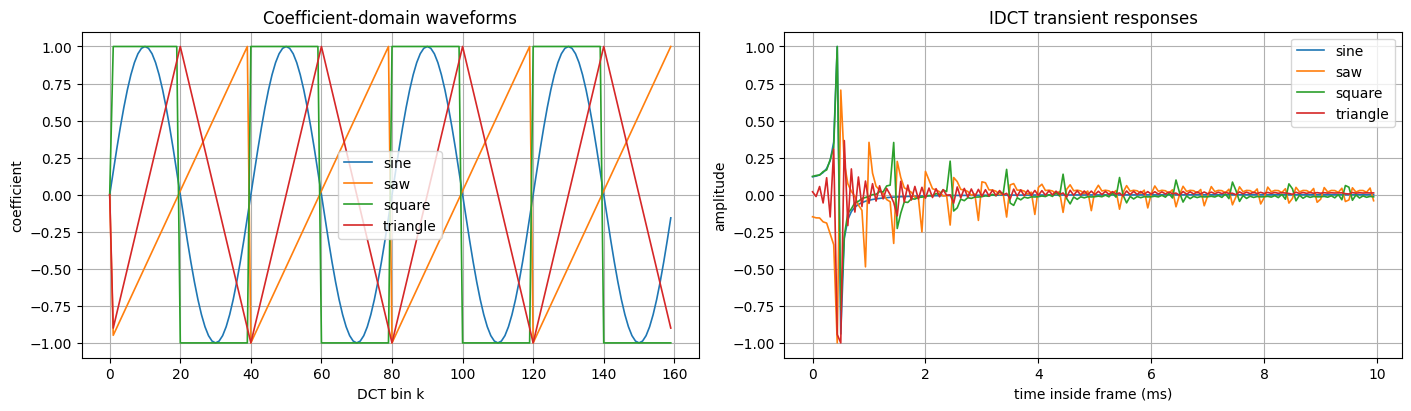

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)

for kind in wave_types:
    axes[0].plot(np.arange(N), profiles[kind], label=kind, linewidth=1.2)
    axes[1].plot(time_ms, responses[kind], label=kind, linewidth=1.2)

axes[0].set_title('Coefficient-domain waveforms')
axes[0].set_xlabel('DCT bin k')
axes[0].set_ylabel('coefficient')
axes[0].legend()

axes[1].set_title('IDCT transient responses')
axes[1].set_xlabel('time inside frame (ms)')
axes[1].set_ylabel('amplitude')
axes[1].legend()

plt.show()


## Sine-in-DCT-Domain Frequency Sweep

DDSP-SFX states that changing the sinusoid frequency in the DCT domain changes the time location/timbre of the short impulse. This cell sweeps the number of DCT-domain cycles and marks the strongest time-domain peak.


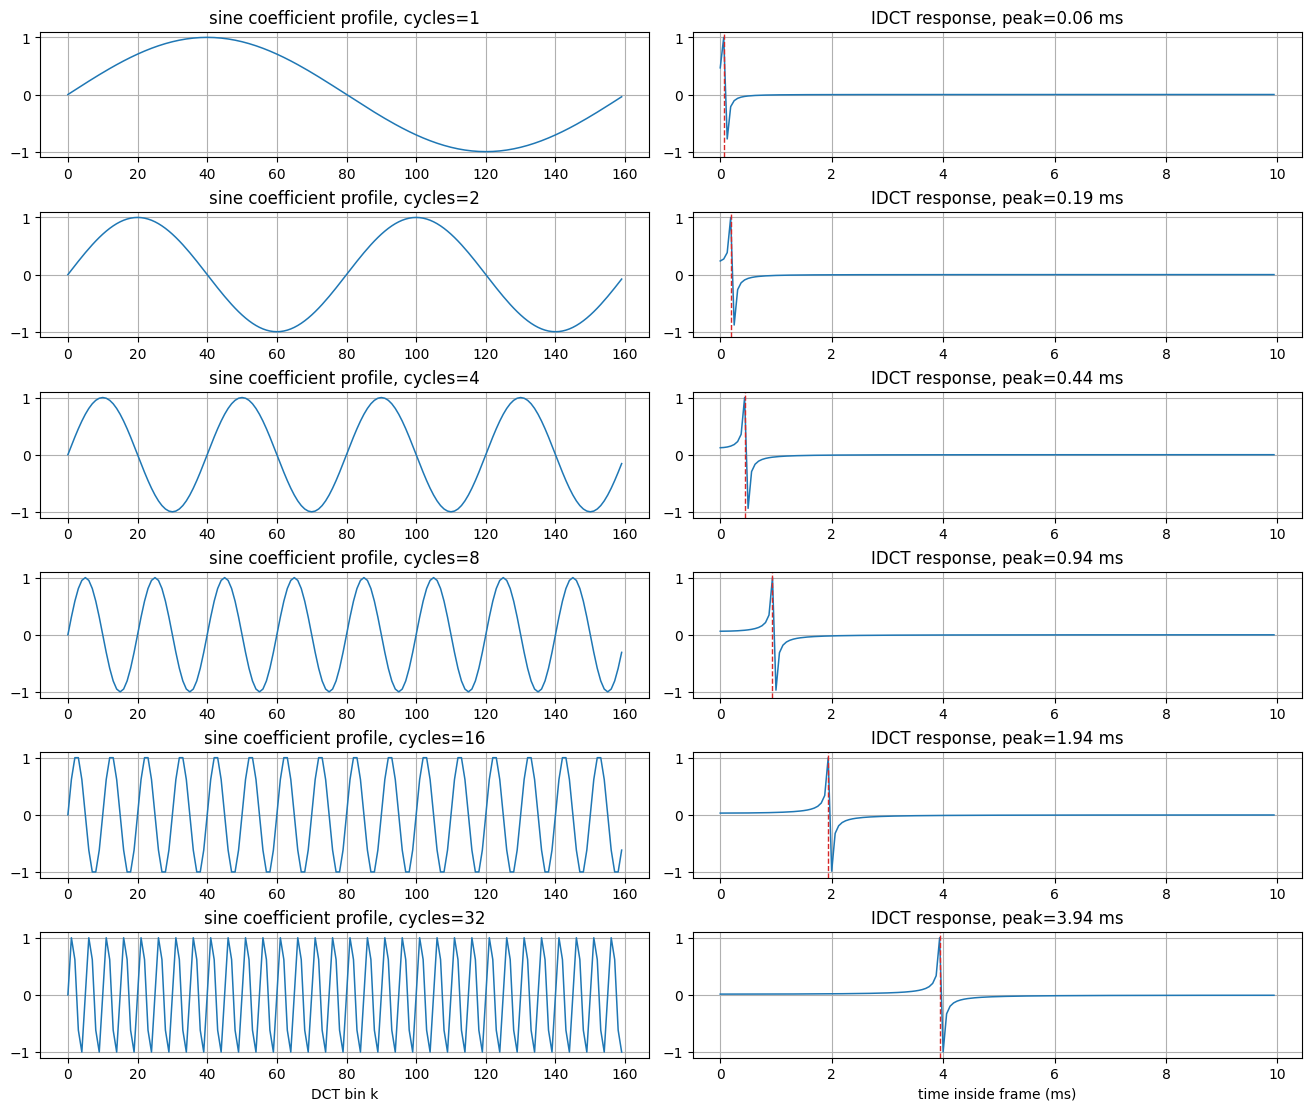

In [5]:
sweep_cycles = [1, 2, 4, 8, 16, 32]
fig, axes = plt.subplots(len(sweep_cycles), 2, figsize=(13, 11), constrained_layout=True)

for row, cycles in enumerate(sweep_cycles):
    coeff = make_dct_profile('sine', cycles=cycles)
    x = idct_transient(coeff)
    peak_idx = int(np.argmax(np.abs(x)))

    axes[row, 0].plot(np.arange(N), coeff, linewidth=1.1)
    axes[row, 0].set_title(f'sine coefficient profile, cycles={cycles}')
    axes[row, 0].set_ylim(-1.1, 1.1)

    axes[row, 1].plot(time_ms, x, linewidth=1.1)
    axes[row, 1].axvline(time_ms[peak_idx], color='tab:red', linestyle='--', linewidth=1.0)
    axes[row, 1].set_title(f'IDCT response, peak={time_ms[peak_idx]:.2f} ms')
    axes[row, 1].set_ylim(-1.1, 1.1)

for ax in axes[-1, :]:
    ax.set_xlabel('DCT bin k' if ax is axes[-1, 0] else 'time inside frame (ms)')

plt.show()


## Audition as Click Trains

A single 10 ms transient is too short to audition comfortably, so this repeats each transient every 250 ms. The zeros between clicks are only for playback.


In [6]:
def make_click_train(x, sr=sr, repeats=8, gap_seconds=0.25, gain=0.8):
    gap = np.zeros(int(round(gap_seconds * sr)), dtype=np.float64)
    click = normalize_peak(x) * gain
    return np.concatenate([np.concatenate([click, gap]) for _ in range(repeats)])

for kind in wave_types:
    audio = make_click_train(responses[kind])
    print(f'{kind} coefficient profile -> IDCT transient click train')
    display(Audio(audio, rate=sr))


sine coefficient profile -> IDCT transient click train


saw coefficient profile -> IDCT transient click train


square coefficient profile -> IDCT transient click train


triangle coefficient profile -> IDCT transient click train


## Try Your Own Settings

Change these values and rerun the following cell:

- `kind`: `'sine'`, `'saw'`, `'square'`, or `'triangle'`
- `cycles`: DCT-domain frequency. This strongly changes peak location and transient timbre.
- `phase`: phase offset on the coefficient-domain waveform.
- `taper_strength`: optional high-bin rolloff. `0` means raw profile; larger values make the transient smoother and less bright.


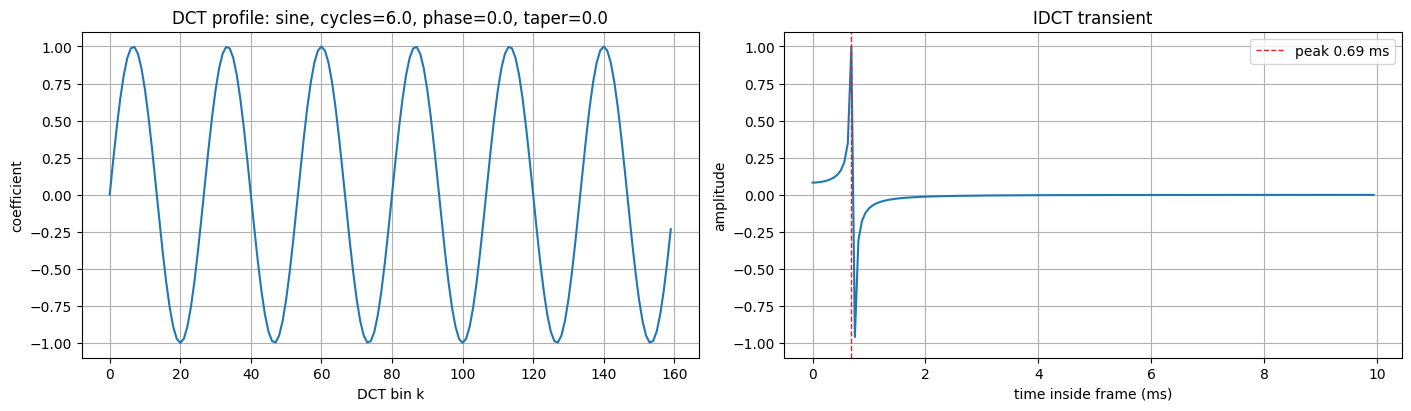

In [7]:
kind = 'sine'
cycles = 6.0
phase = 0.0
taper_strength = 0.0

coeff = make_dct_profile(kind, cycles=cycles, phase=phase, taper_strength=taper_strength)
x = idct_transient(coeff)
peak_idx = int(np.argmax(np.abs(x)))

fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
axes[0].plot(np.arange(N), coeff)
axes[0].set_title(f'DCT profile: {kind}, cycles={cycles}, phase={phase}, taper={taper_strength}')
axes[0].set_xlabel('DCT bin k')
axes[0].set_ylabel('coefficient')
axes[0].set_ylim(-1.1, 1.1)

axes[1].plot(time_ms, x)
axes[1].axvline(time_ms[peak_idx], color='tab:red', linestyle='--', linewidth=1.0, label=f'peak {time_ms[peak_idx]:.2f} ms')
axes[1].set_title('IDCT transient')
axes[1].set_xlabel('time inside frame (ms)')
axes[1].set_ylabel('amplitude')
axes[1].set_ylim(-1.1, 1.1)
axes[1].legend()
plt.show()

display(Audio(make_click_train(x), rate=sr))
